In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Exploratory Data Analysis :

In [2]:
data = pd.read_csv('wine.csv')

In [3]:
data.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [5]:
data.isnull().sum()

Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

#### visualization:

#### 1. Histogram :

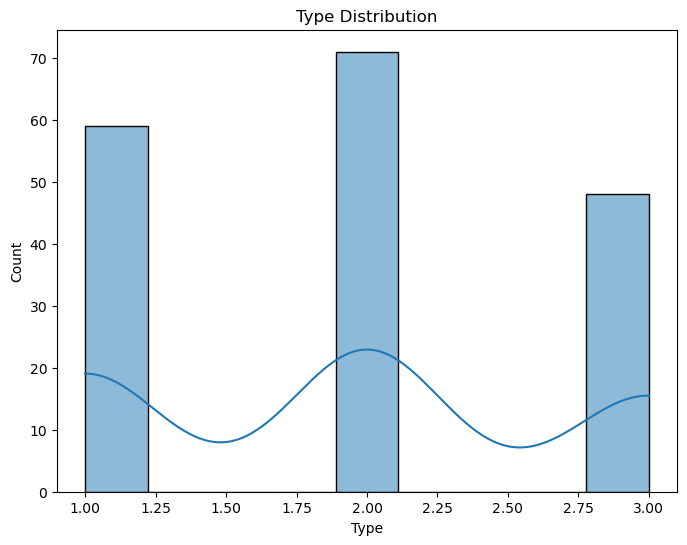

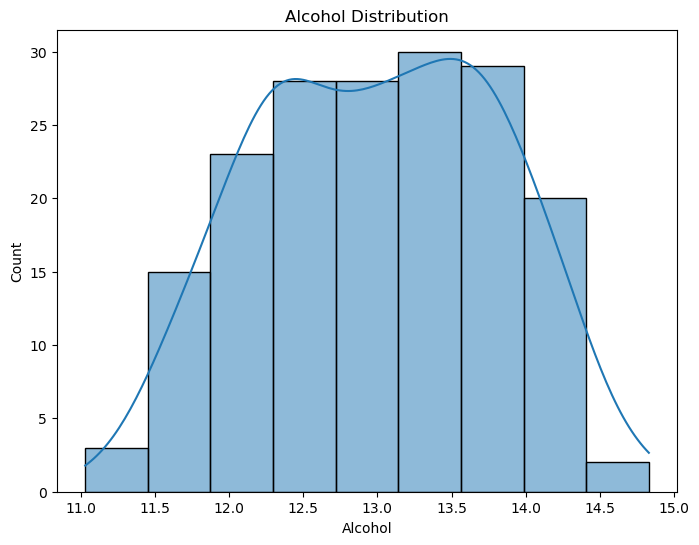

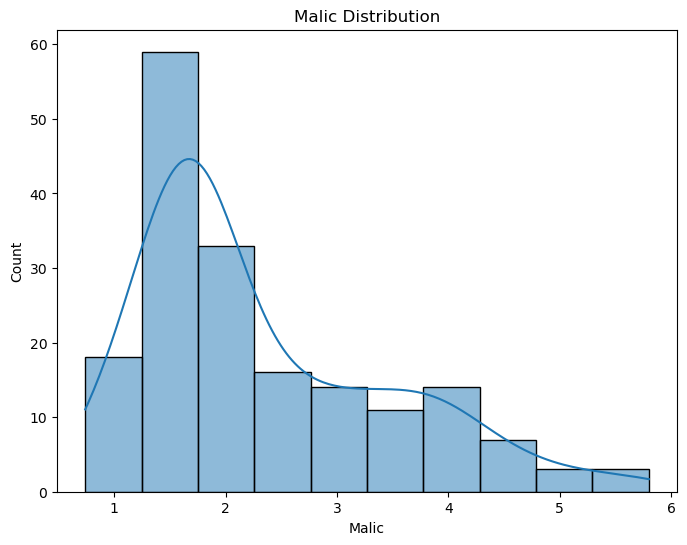

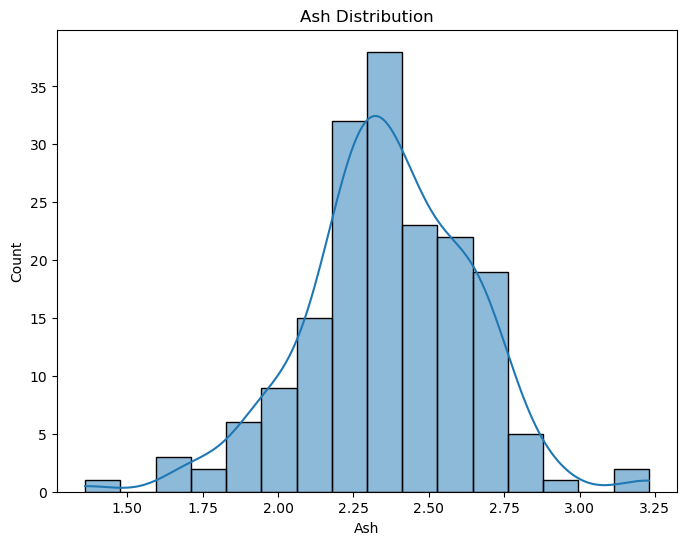

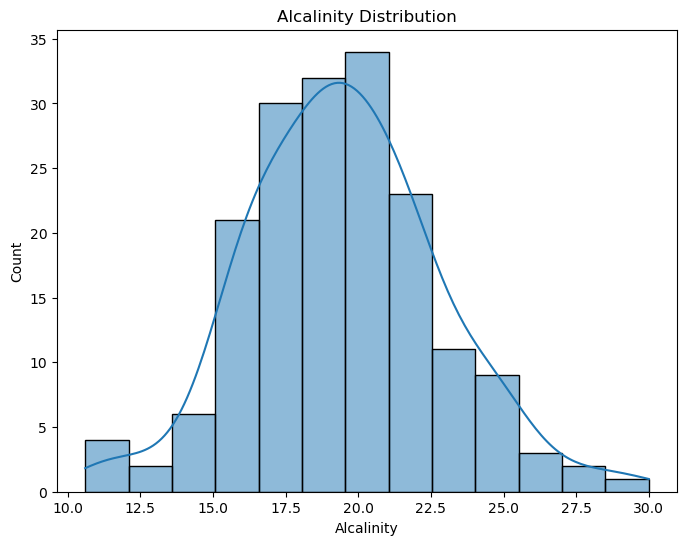

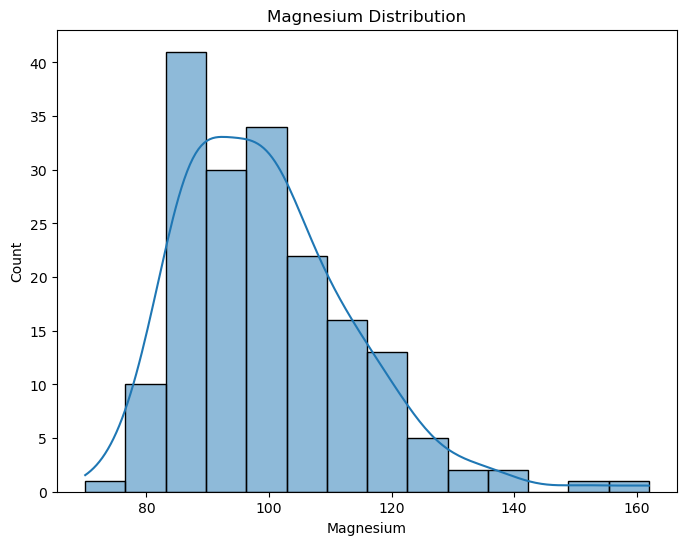

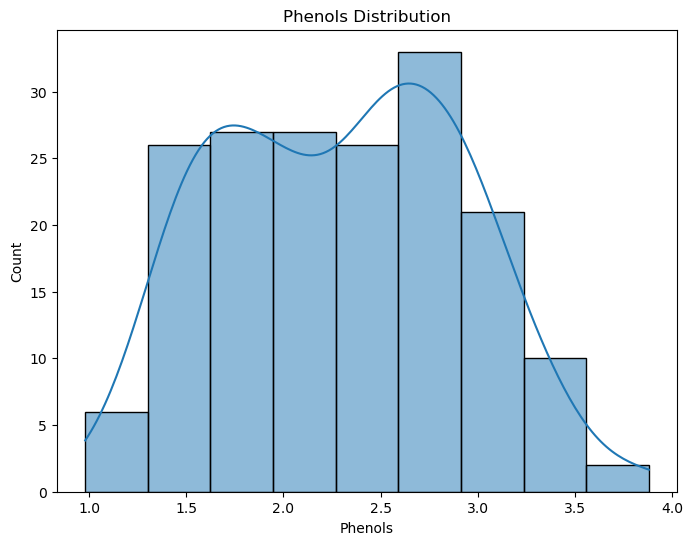

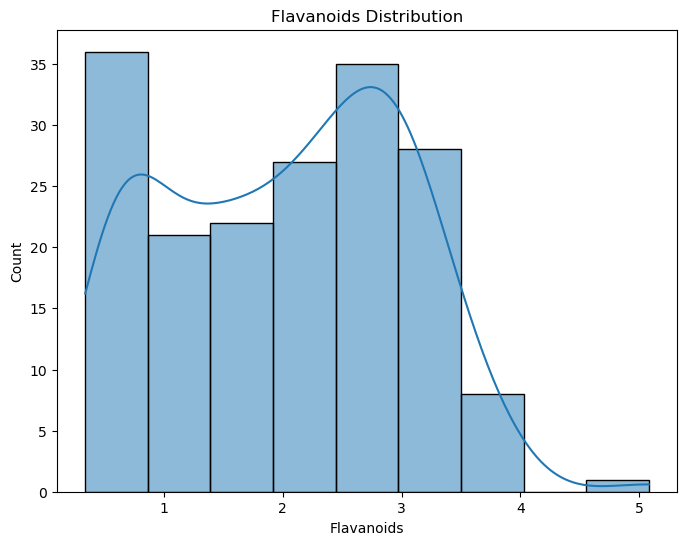

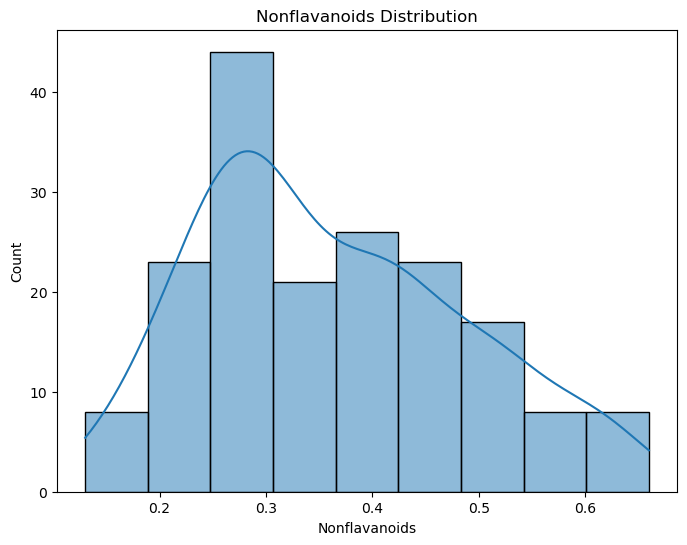

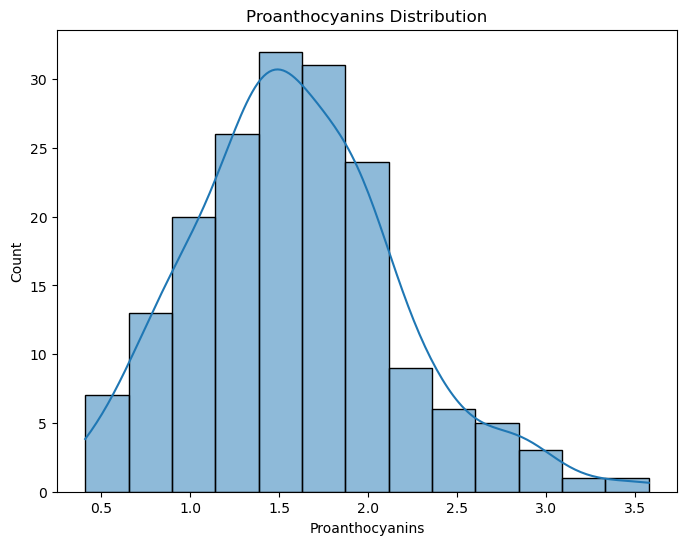

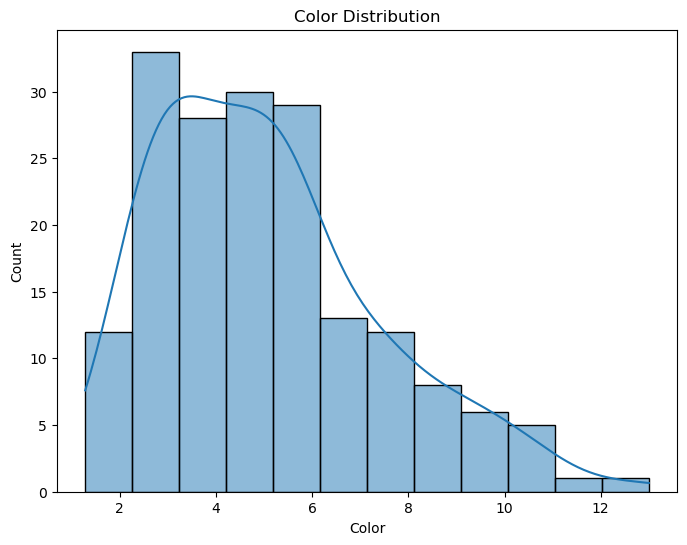

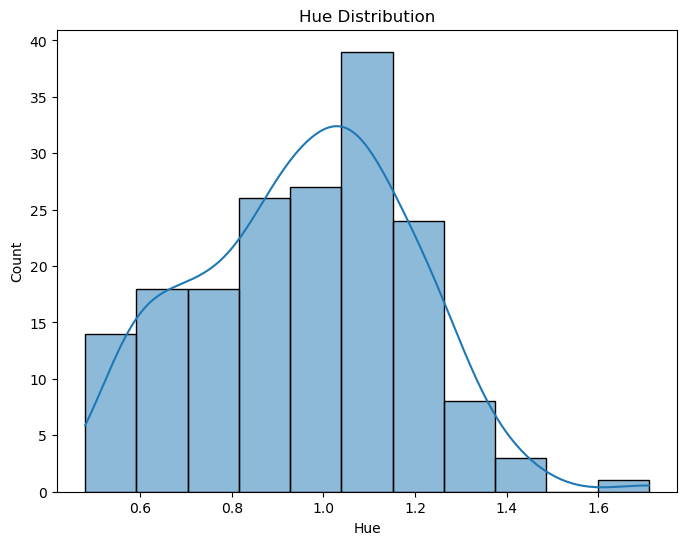

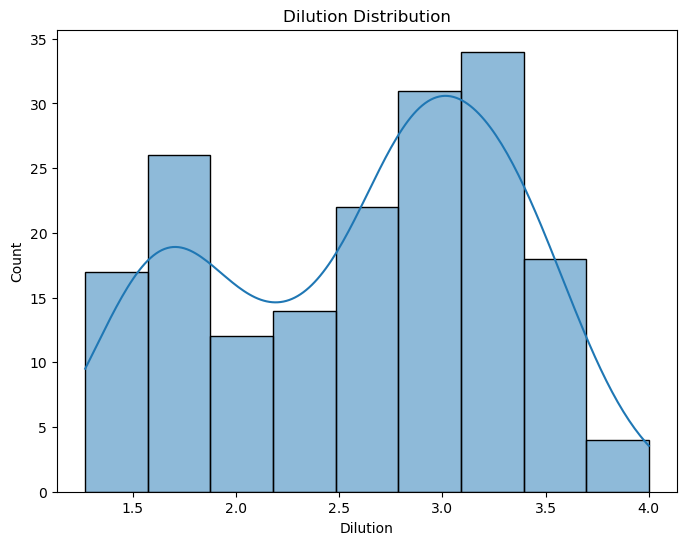

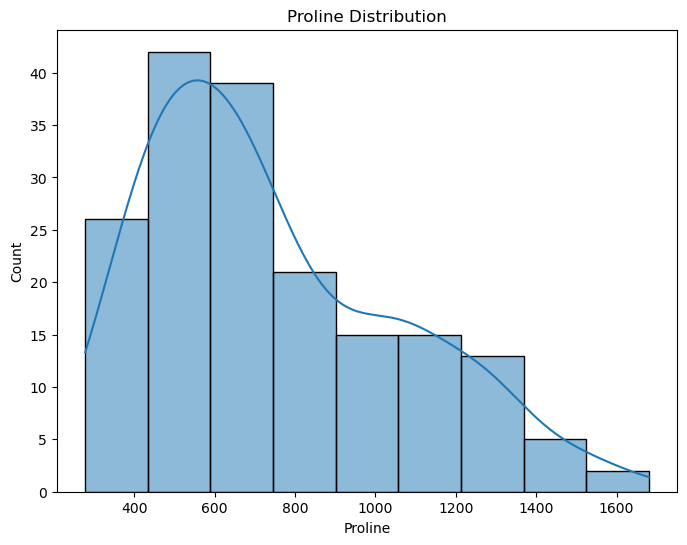

In [6]:
for col in data.columns:
    plt.figure(figsize=(8,6))
    sns.histplot(data[col],kde=True)
    plt.title(f'{col} Distribution')
    plt.show

In [7]:
for col in data.columns:
    print(f"Skewness of {col} :",data[col].skew())

Skewness of Type : 0.10743112358094281
Skewness of Alcohol : -0.051482331077134784
Skewness of Malic : 1.0396511925814442
Skewness of Ash : -0.17669931645735712
Skewness of Alcalinity : 0.21304688642645586
Skewness of Magnesium : 1.098191054755161
Skewness of Phenols : 0.08663858640245253
Skewness of Flavanoids : 0.02534355338149103
Skewness of Nonflavanoids : 0.4501513355621236
Skewness of Proanthocyanins : 0.5171371722998975
Skewness of Color : 0.8685847909572548
Skewness of Hue : 0.021091272199709302
Skewness of Dilution : -0.30728549895848106
Skewness of Proline : 0.7678217813897322


#### Boxplot :

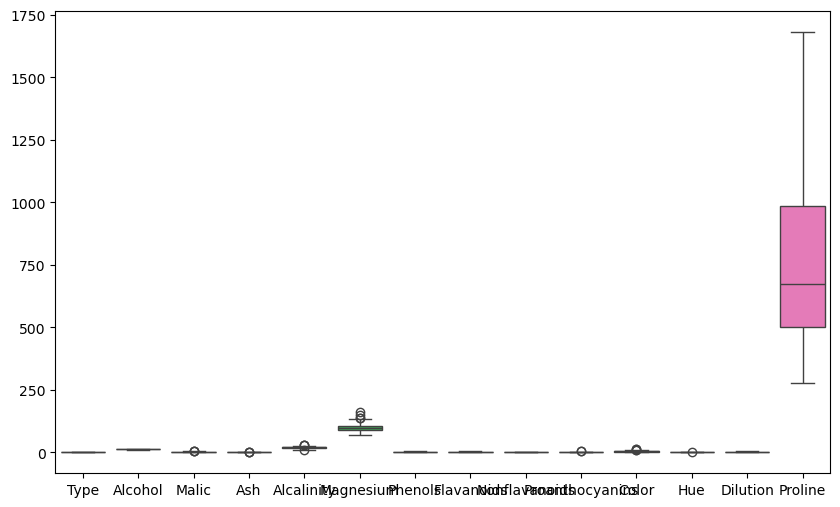

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data)
plt.show()

#### According to boxplot very less outliers are present in the dataset.

In [9]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    outliers = data[(data[col]>upper_bound) | (data[col]<lower_bound)]
    print(f'Outliers in {col} :',outliers.shape[0])

Outliers in Type : 0
Outliers in Alcohol : 0
Outliers in Malic : 3
Outliers in Ash : 3
Outliers in Alcalinity : 4
Outliers in Magnesium : 4
Outliers in Phenols : 0
Outliers in Flavanoids : 0
Outliers in Nonflavanoids : 0
Outliers in Proanthocyanins : 2
Outliers in Color : 4
Outliers in Hue : 1
Outliers in Dilution : 0
Outliers in Proline : 0


In [10]:
for col in data.columns :
    Q3 = data[col].quantile(0.75)
    Q1 = data[col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + IQR*1.5
    lower_bound = Q1 - IQR*1.5
    data[col] = data[col].clip(upper_bound,lower_bound)

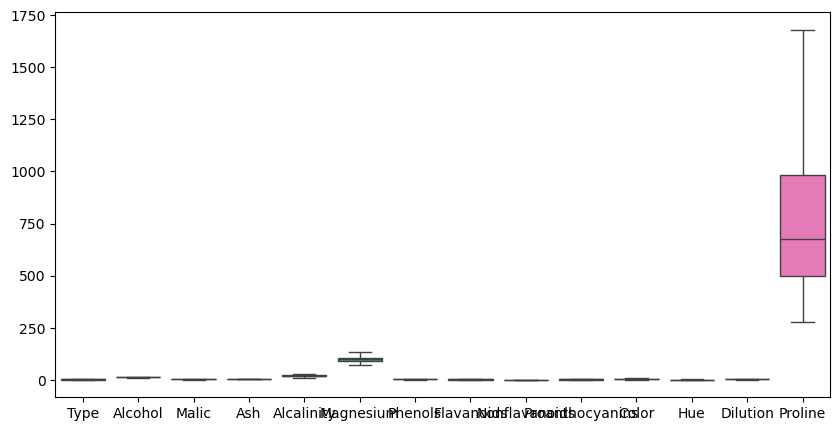

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data)
plt.show()

#### Corelation Heatmap :

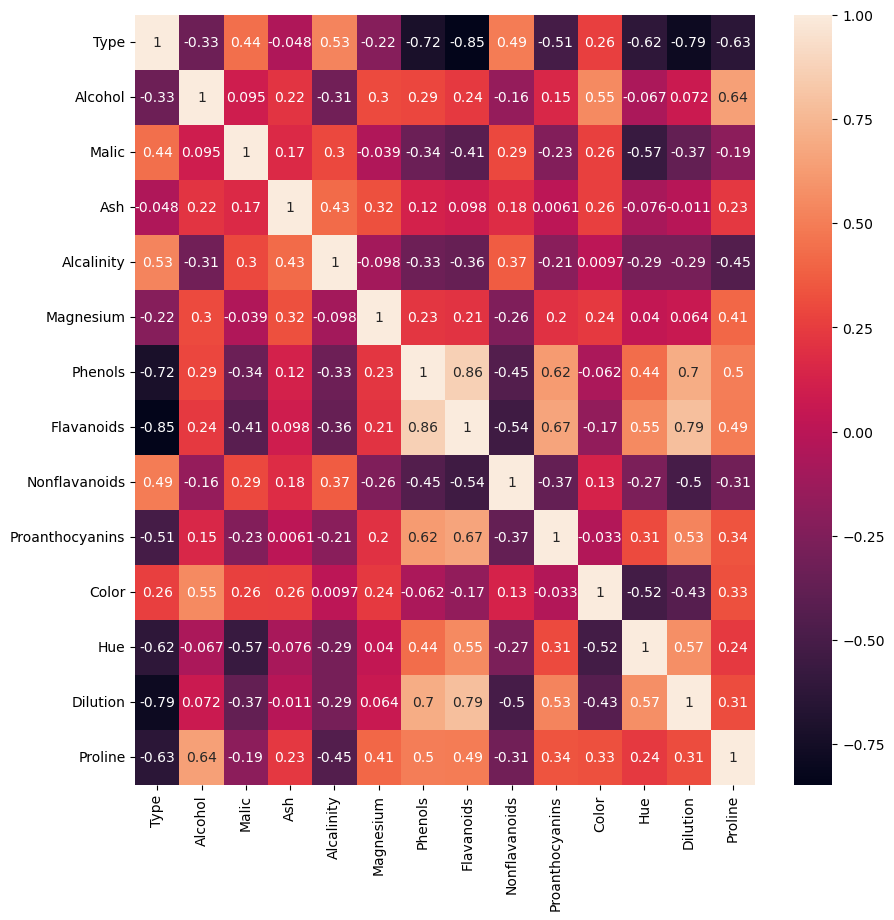

In [12]:
plt.figure(figsize=(10,10))
sns.heatmap(data.corr(),annot=True)
plt.show()

#### 2. Dimensionality Reduction with PCA:

#### Standardization :

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
Scaler = StandardScaler()
Scaled_data = Scaler.fit_transform(data)

In [15]:
Scaled_data.shape

(178, 14)

In [16]:
from sklearn.decomposition import PCA

In [21]:
pca = PCA()
pca.fit(Scaled_data)

PCA()

#### Scree Plot :

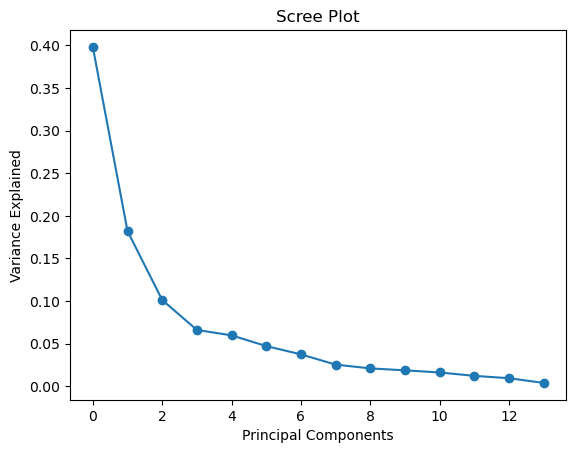

In [22]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Components")
plt.ylabel("Variance Explained")
plt.title("Scree Plot")
plt.show()

#### Cumulative Variance :

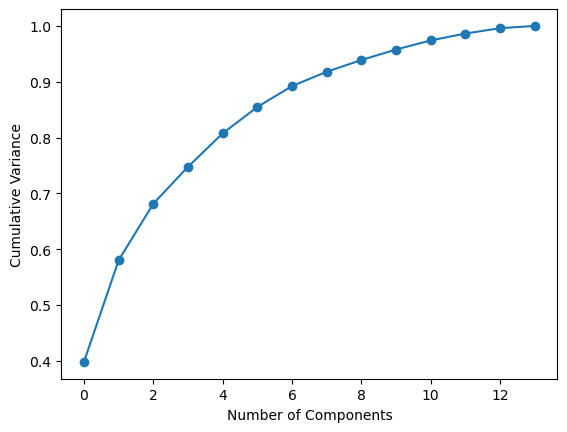

In [23]:
import numpy as np

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

#### Transform Data:

In [25]:
pca = PCA(n_components=3) 
X_pca = pca.fit_transform(Scaled_data)

In [26]:
X_pca.shape

(178, 3)

#### We can see the shape of data before and after dimension reductions...

#### Task 3: Clustering (Original Data)

#### Apply K-Means :

In [28]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(Scaled_data)

#### Visualization :

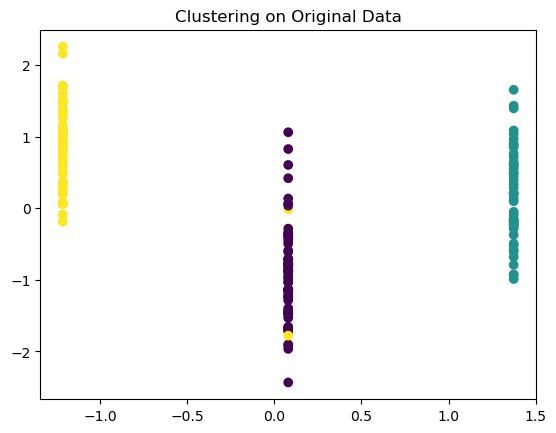

In [31]:
plt.scatter(Scaled_data[:,0], Scaled_data[:,1], c=labels)
plt.title("Clustering on Original Data")
plt.show()

#### Evaluation :

In [33]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

print("Silhouette Score:", silhouette_score(Scaled_data, labels))
print("Davies-Bouldin Index:", davies_bouldin_score(Scaled_data, labels))

Silhouette Score: 0.3069772963964642
Davies-Bouldin Index: 1.3098589498896416


#### Clustering (PCA Data) :

In [34]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

#### Visualization :

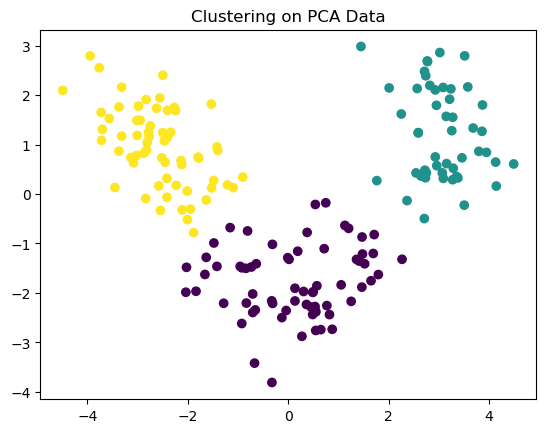

In [35]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.title("Clustering on PCA Data")
plt.show()

#### Evaluation :

In [36]:
print("Silhouette Score (PCA):", silhouette_score(X_pca, labels_pca))
print("Davies-Bouldin Index (PCA):", davies_bouldin_score(X_pca, labels_pca))

Silhouette Score (PCA): 0.4873940826367193
Davies-Bouldin Index (PCA): 0.7756762041782279


#### 5. Comparison & Analysis :

#### What to Write in Assignment
#### Similarities:

##### - Cluster patterns may look similar if data has strong structure
##### - Key groups still preserved after PCA

#### Differences:
##### - PCA reduces noise → clusters may be clearer
##### - Some information loss → clusters may shift

#### Impact of PCA:

##### - Faster computation
##### - Better visualization
##### - Removes multicollinearity

#### 6. Conclusion & Insights :

### Conclusion :

#### - PCA helped reduce dimensionality while retaining most of the important information.
#### - Clustering on PCA-transformed data was faster and sometimes produced clearer clusters.
#### - However, slight loss of information affected cluster precision.
#### - Silhouette and Davies–Bouldin scores helped evaluate clustering quality.

#### Recommendation:

#### Use PCA when:
##### - High-dimensional data
##### - Visualization needed
##### - Features are highly correlated
#### Use original data when:
##### - Dataset is small
##### - All features are important
##### - Interpretability is required